In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "stixsans"
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11


coordinate system

$ bca \equiv xyz $
so that $ n_z > n_y > n_x $

In [2]:
def BMF_refractive_index(wavelength_nm, polarization):
    if polarization not in ["a", "b", "c"]:
        raise ValueError("Polarization must be 'a', 'b', or 'c'.")

    wl = wavelength_nm * 1e-3  # Convert nm to micrometers
    A = [2.1479, 2.07977, 2.1285]
    B = [0.00726962, 0.00650243, 0.00704687]
    C = [0.00965209, 0.0100106, 0.00999784]
    D = [8.10153, 8.18289, 8.56752]
    E = [1394.25, 1451.04, 1413.17]
    F = [0.00320462, 0.00321466, 0.00331969]

    idx = {"a": 0, "b": 1, "c": 2}[polarization]
    n_squared = (A[idx] + B[idx] / (wl**2 - C[idx]) + D[idx] * wl**2 / (wl**2 - E[idx]) + F[idx] * wl**2)
    return np.sqrt(n_squared)


In [3]:
wavelength_array = np.arange(150, 1200.1, 0.1)
nx_array = BMF_refractive_index(wavelength_array, "b")
ny_array = BMF_refractive_index(wavelength_array, "c")
nz_array = BMF_refractive_index(wavelength_array, "a")


Angle $V_z$

$V_z$ is the angle between the optic axis and z-axis
$$ \cot^2{V_z} = \frac{n_x^2 (n_z^2 - n_y^2)}{n_z^2 (n_y^2 - n_x^2)} $$

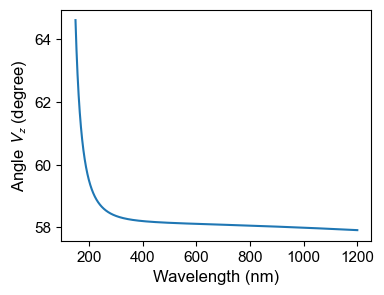

In [4]:
cotVz = np.sqrt(nx_array**2 * (nz_array**2 - ny_array**2) / (nz_array**2 * (ny_array**2 - nx_array**2)))
Vz = np.arctan(1/cotVz) * (180 / np.pi)  # in degrees

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(wavelength_array, Vz)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Angle $V_z$ (degree)")
plt.show()


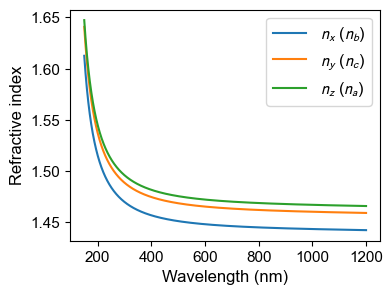

In [5]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(wavelength_array, nx_array, label="$n_x$ ($n_b$)")
ax.plot(wavelength_array, ny_array, label="$n_y$ ($n_c$)")
ax.plot(wavelength_array, nz_array, label="$n_z$ ($n_a$)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Refractive index")
# ax.set_xlim(200, None)

ax.legend()
plt.show()


k-vector in xy-plane (bc-plane) ($\theta=90°$)

Type-I phase-matching (oo-e)

$$ \sin^2{\phi} = \frac{n_x^2(\lambda/2)\left[ n_z^2(\lambda) - n_y^2(\lambda/2) \right]}{n_z^2(\lambda)\left[ n_x^2(\lambda/2) - n_y^2(\lambda/2) \right]} $$

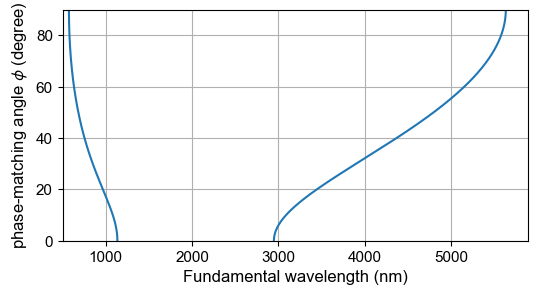

In [6]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

wl_fw_array = np.arange(500, 6000, 0.1)
wl_sh_array = wl_fw_array * 0.5

nx_sh = BMF_refractive_index(wl_sh_array, "b")
ny_sh = BMF_refractive_index(wl_sh_array, "c")
nz_fw = BMF_refractive_index(wl_fw_array, "a")

S = (nx_sh**2 * (nz_fw**2 - ny_sh**2)) / (nz_fw**2 * (nx_sh**2 - ny_sh**2))
phi_xy_ooe = np.arcsin(np.sqrt(S))
if np.all(np.isnan(phi_xy_ooe)):
    print("no phase-matching condition!")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(wl_fw_array, phi_xy_ooe*180/np.pi)
ax.set_xlabel("Fundamental wavelength (nm)")
ax.set_ylabel("phase-matching angle $\\phi$ (degree)")
ax.set_xlim(500, None)
ax.set_ylim(0, 90)
ax.grid()
plt.show()


Type-I phase-matching (ee-o)

$$ \sin^2{\phi} = \frac{n_x^2(\lambda)\left[ n_z^2(\lambda/2) - n_y^2(\lambda) \right]}{n_z^2(\lambda/2)\left[ n_x^2(\lambda) - n_y^2(\lambda) \right]} $$

In [7]:
nx_fw = BMF_refractive_index(wl_fw_array, "b")
ny_fw = BMF_refractive_index(wl_fw_array, "c")
nz_sh = BMF_refractive_index(wl_sh_array, "a")

S = (nx_fw**2 * (nz_sh**2 - ny_fw**2)) / (nz_sh**2 * (nx_fw**2 - ny_fw**2))
phi_xy_eeo = np.arcsin(np.sqrt(S))

if np.all(np.isnan(phi_xy_eeo)):
    print("no phase-matching condition!")


no phase-matching condition!


Type-II phase matching (eo-e)

$$ f(\phi, \lambda) = n_{xy}(\phi, \lambda) + n_z(\lambda) - 2n_{xy}(\phi, \lambda/2) = 0 $$
Numerically solve this equation using Brent method

In [8]:
from scipy.optimize import brentq

def n_xy(phi, nx, ny):
    # phi in radian!
    return nx * ny / np.sqrt(nx**2 * np.cos(phi)**2 + ny**2 * np.sin(phi)**2)


def f(phi, nx_fw, ny_fw, nz_fw, nx_sh, ny_sh):
    return n_xy(phi, nx_fw, ny_fw) + nz_fw - 2 * n_xy(phi, nx_sh, ny_sh)


phi_xy_eoe = np.array([])
for wl_fw in wl_fw_array:
    wl_sh = wl_fw * 0.5
    nx_fw = BMF_refractive_index(wl_fw, "b")
    ny_fw = BMF_refractive_index(wl_fw, "c")
    nz_fw = BMF_refractive_index(wl_fw, "a")
    nx_sh = BMF_refractive_index(wl_sh, "b")
    ny_sh = BMF_refractive_index(wl_sh, "c")

    phis = np.linspace(0, np.pi*0.5, 1000)
    vals = f(phis, nx_fw, ny_fw, nz_fw, nx_sh, ny_sh)

    phi_solution = np.nan
    for i in range(len(vals) - 1):
        if vals[i] * vals[i+1] < 0:
            a = phis[i]
            b = phis[i+1]
            phi_solution = brentq(f, a, b, args=(nx_fw, ny_fw, nz_fw, nx_sh, ny_sh))
            break
    phi_xy_eoe = np.append(phi_xy_eoe, phi_solution)

if np.all(np.isnan(phi_xy_eoe)):
    print("no phase-matching condition!")


Type-II phase matching (eo-o)

$$ f(\phi, \lambda) = n_{xy}(\phi, \lambda) + n_z(\lambda) - 2n_{z}(\lambda/2) = 0 $$

In [9]:
def f(phi, nx_fw, ny_fw, nz_fw, nz_sh):
    return n_xy(phi, nx_fw, ny_fw) + nz_fw - 2 * nz_sh


phi_xy_eoo = np.array([])
for wl_fw in wl_fw_array:
    wl_sh = wl_fw * 0.5
    nx_fw = BMF_refractive_index(wl_fw, "b")
    ny_fw = BMF_refractive_index(wl_fw, "c")
    nz_fw = BMF_refractive_index(wl_fw, "a")
    nz_sh = BMF_refractive_index(wl_sh, "a")

    phis = np.linspace(0, np.pi*0.5, 1000)
    vals = f(phis, nx_fw, ny_fw, nz_fw, nz_sh)

    phi_solution = np.nan
    for i in range(len(vals) - 1):
        if vals[i] * vals[i+1] < 0:
            a = phis[i]
            b = phis[i+1]
            phi_solution = brentq(f, a, b, args=(nx_fw, ny_fw, nz_fw, nz_sh))
            break
    phi_xy_eoo = np.append(phi_xy_eoo, phi_solution)

if np.all(np.isnan(phi_xy_eoo)):
    print("no phase-matching condition!")


no phase-matching condition!


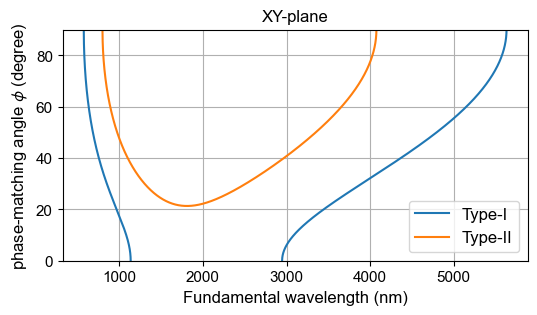

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(wl_fw_array, phi_xy_ooe*180/np.pi, label="Type-I")
ax.plot(wl_fw_array, phi_xy_eoe*180/np.pi, label="Type-II")
ax.set_xlabel("Fundamental wavelength (nm)")
ax.set_ylabel("phase-matching angle $\\phi$ (degree)")
ax.set_title("XY-plane")
# ax.set_xlim(600, 1200)
ax.set_ylim(0, 90)
ax.grid()
ax.legend(loc="lower right")
plt.show()


k-vector in yz-plane (ac-plane) ($\phi=90°$)

Type-I phase-matching (oo-e)

$$ \sin^2{\theta} = \frac{n_z^2(\lambda/2)\left[ n_x^2(\lambda) - n_y^2(\lambda/2) \right]}{n_x^2(\lambda)\left[ n_z^2(\lambda/2) - n_y^2(\lambda/2) \right]} $$

In [11]:
nx_fw = BMF_refractive_index(wl_fw_array, "b")
ny_sh = BMF_refractive_index(wl_sh_array, "c")
nz_sh = BMF_refractive_index(wl_sh_array, "a")

S = (nz_sh**2 * (nx_fw**2 - ny_sh**2)) / (nx_fw**2 * (nz_sh**2 - ny_sh**2))
phi_yz_ooe = np.arcsin(np.sqrt(S))

if np.all(np.isnan(phi_yz_ooe)):
    print("no phase-matching condition!")


no phase-matching condition!


Type-I phase-matching (ee-o)

$$ \sin^2{\theta} = \frac{n_z^2(\lambda)\left[ n_x^2(\lambda/2) - n_y^2(\lambda) \right]}{n_x^2(\lambda/2)\left[ n_z^2(\lambda) - n_y^2(\lambda) \right]} $$

In [12]:
nx_sh = BMF_refractive_index(wl_sh_array, "b")
ny_fw = BMF_refractive_index(wl_fw_array, "c")
nz_fw = BMF_refractive_index(wl_fw_array, "a")

S = (nz_fw**2 * (nx_sh**2 - ny_fw**2)) / (nx_sh**2 * (nz_fw**2 - ny_fw**2))
theta_yz_eeo = np.arcsin(np.sqrt(S))

if np.all(np.isnan(theta_yz_eeo)):
    print("no phase-matching condition!")


Type-II phase-matching (oe-e)

$$ f(\theta, \lambda) = n_x(\lambda) + n_{yz}(\theta, \lambda) - 2n_{yz}(\theta, \lambda/2) = 0 $$

In [13]:
def n_yz(theta, ny, nz):
    # theta in radian!
    return ny * nz / np.sqrt(nz**2 * np.cos(theta)**2 + ny**2 * np.sin(theta)**2)

def f(theta, nx_fw, ny_fw, nz_fw, ny_sh, nz_sh):
    return n_yz(theta, ny_fw, nz_fw) + nx_fw - 2 * n_yz(theta, ny_sh, nz_sh)

theta_yz_oee = np.array([])
for wl_fw in wl_fw_array:
    wl_sh = wl_fw * 0.5
    nx_fw = BMF_refractive_index(wl_fw, "b")
    ny_fw = BMF_refractive_index(wl_fw, "c")
    ny_sh = BMF_refractive_index(wl_sh, "c")
    nz_fw = BMF_refractive_index(wl_fw, "a")
    nz_sh = BMF_refractive_index(wl_sh, "a")

    thetas = np.linspace(0, np.pi*0.5, 1000)
    vals = f(thetas, nx_fw, ny_fw, nz_fw, ny_sh, nz_sh)

    theta_solution = np.nan
    for i in range(len(vals) - 1):
        if vals[i] * vals[i+1] < 0:
            a = thetas[i]
            b = thetas[i+1]
            theta_solution = brentq(f, a, b, args=(nx_fw, ny_fw, nz_fw, ny_sh, nz_sh))
            break
    theta_yz_oee = np.append(theta_yz_oee, theta_solution)

if np.all(np.isnan(theta_yz_oee)):
    print("no phase-matching condition!")


no phase-matching condition!


In [14]:
def f(theta, nx_fw, ny_fw, nz_fw, nx_sh):
    return n_yz(theta, ny_fw, nz_fw) + nx_fw - 2 * nx_sh

theta_yz_oeo = np.array([])
for wl_fw in wl_fw_array:
    wl_sh = wl_fw * 0.5
    nx_fw = BMF_refractive_index(wl_fw, "b")
    nx_sh = BMF_refractive_index(wl_sh, "b")
    ny_fw = BMF_refractive_index(wl_fw, "c")
    nz_fw = BMF_refractive_index(wl_fw, "a")

    thetas = np.linspace(0, np.pi*0.5, 1000)
    vals = f(thetas, nx_fw, ny_fw, nz_fw, nx_sh)

    theta_solution = np.nan
    for i in range(len(vals) - 1):
        if vals[i] * vals[i+1] < 0:
            a = thetas[i]
            b = thetas[i+1]
            theta_solution = brentq(f, a, b, args=(nx_fw, ny_fw, nz_fw, nx_sh))
            break
    theta_yz_oeo = np.append(theta_yz_oeo, theta_solution)

if np.all(np.isnan(theta_yz_oeo)):
    print("no phase-matching condition!")


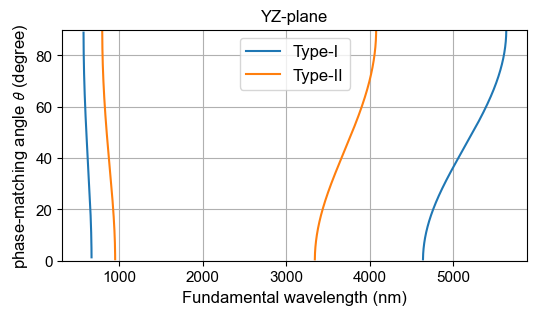

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(wl_fw_array, theta_yz_eeo*180/np.pi, label="Type-I")
ax.plot(wl_fw_array, theta_yz_oeo*180/np.pi, label="Type-II")
ax.set_xlabel("Fundamental wavelength (nm)")
ax.set_ylabel("phase-matching angle $\\theta$ (degree)")
ax.set_title("YZ-plane")
ax.set_xlim(None, None)
ax.set_ylim(0, 90)
ax.grid()
ax.legend(loc="best")
plt.show()


k-vector in xz-plane (ab-plane) ($\phi=0°$)

Type-I phase-matching (ee-o)

$$ \sin^2{\theta} = \frac{n_z^2(\lambda)\left[ n_y^2(\lambda/2) - n_x^2(\lambda) \right]}{n_y^2(\lambda/2)\left[ n_z^2(\lambda) - n_x^2(\lambda) \right]} $$

In [16]:
nx_fw = BMF_refractive_index(wl_fw_array, "b")
ny_sh = BMF_refractive_index(wl_sh_array, "c")
nz_fw = BMF_refractive_index(wl_fw_array, "a")

S = (nz_fw**2 * (ny_sh**2 - nx_fw**2)) / (ny_sh**2 * (nz_fw**2 - nx_fw**2))
theta_xz_eeo = np.arcsin(np.sqrt(S))

if np.all(np.isnan(theta_xz_eeo)):
    print("no phase-matching condition!")



Type-I phase-matching (oo-e)

$$ \sin^2{\theta} = \frac{n_z^2(\lambda/2)\left[ n_x^2(\lambda/2) - n_y^2(\lambda) \right]}{n_y^2(\lambda)\left[ n_x^2(\lambda/2) - n_z^2(\lambda/2) \right]} $$

In [17]:
ny_fw = BMF_refractive_index(wl_fw_array, "c")
nx_sh = BMF_refractive_index(wl_sh_array, "b")
nz_sh = BMF_refractive_index(wl_sh_array, "a")

S = (nz_sh**2 * (nx_sh**2 - ny_fw**2)) / (ny_fw**2 *(nx_sh**2 - nz_sh**2))
theta_xz_ooe = np.arcsin(np.sqrt(S))

if np.all(np.isnan(theta_xz_ooe)):
    print("no phase-matching condition!")

Type-II phase-matching (oe-e)

$$ f(\theta, \lambda) = n_y(\lambda) + n_{xz}(\theta, \lambda) - 2n_{xz}(\theta, \lambda/2) = 0 $$

In [18]:
def n_xz(theta, nx, nz):
    # theta in radian!
    return nx * nz / np.sqrt(nz**2 * np.cos(theta)**2 + nx**2 * np.sin(theta)**2)

def f(theta, nx_fw, ny_fw, nz_fw, nx_sh, nz_sh):
    return n_xz(theta, nx_fw, nz_fw) + ny_fw - 2 * n_xz(theta, nx_sh, nz_sh)

theta_xz_oee = np.array([])
for wl_fw in wl_fw_array:
    wl_sh = wl_fw * 0.5
    nx_fw = BMF_refractive_index(wl_fw, "b")
    nx_sh = BMF_refractive_index(wl_sh, "b")
    ny_fw = BMF_refractive_index(wl_fw, "c")
    nz_fw = BMF_refractive_index(wl_fw, "a")
    nz_sh = BMF_refractive_index(wl_sh, "a")

    thetas = np.linspace(0, np.pi*0.5, 1000)
    vals = f(thetas, nx_fw, ny_fw, nz_fw, nx_sh, nz_sh)

    theta_solution = np.nan
    for i in range(len(vals) - 1):
        if vals[i] * vals[i+1] < 0:
            a = thetas[i]
            b = thetas[i+1]
            theta_solution = brentq(f, a, b, args=(nx_fw, ny_fw, nz_fw, nx_sh, nz_sh))
            break
    theta_xz_oee = np.append(theta_xz_oee, theta_solution)

if np.all(np.isnan(theta_xz_oee)):
    print("no phase-matching condition!")


Type-II phase-matching (oe-o)

$$ f(\theta, \lambda) = n_y(\lambda) + n_{xz}(\theta, \lambda) - 2n_y(\theta, \lambda/2) = 0 $$

In [19]:
def n_xz(theta, nx, nz):
    # theta in radian!
    return nx * nz / np.sqrt(nz**2 * np.cos(theta)**2 + nx**2 * np.sin(theta)**2)

def f(theta, nx_fw, ny_fw, nz_fw, ny_sh):
    return n_xz(theta, nx_fw, nz_fw) + ny_fw - 2 * ny_sh

theta_xz_oeo = np.array([])
for wl_fw in wl_fw_array:
    wl_sh = wl_fw * 0.5
    nx_fw = BMF_refractive_index(wl_fw, "b")
    ny_fw = BMF_refractive_index(wl_fw, "c")
    nz_fw = BMF_refractive_index(wl_fw, "a")

    ny_sh = BMF_refractive_index(wl_sh, "c")

    thetas = np.linspace(0, np.pi*0.5, 1000)
    vals = f(thetas, nx_fw, ny_fw, nz_fw, ny_sh)

    theta_solution = np.nan
    for i in range(len(vals) - 1):
        if vals[i] * vals[i+1] < 0:
            a = thetas[i]
            b = thetas[i+1]
            theta_solution = brentq(f, a, b, args=(nx_fw, ny_fw, nz_fw, ny_sh))
            break
    theta_xz_oeo = np.append(theta_xz_oeo, theta_solution)

if np.all(np.isnan(theta_xz_oeo)):
    print("no phase-matching condition!")


no phase-matching condition!


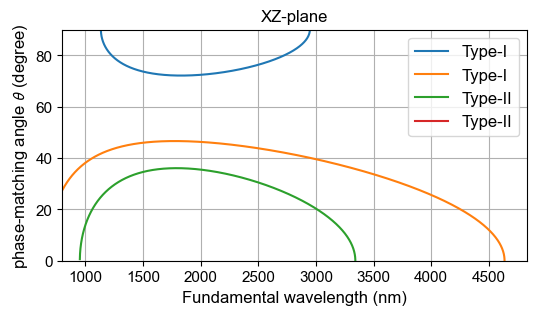

In [20]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(wl_fw_array, theta_xz_eeo*180/np.pi, label="Type-I")
ax.plot(wl_fw_array, theta_xz_ooe*180/np.pi, label="Type-I")
ax.plot(wl_fw_array, theta_xz_oee*180/np.pi, label="Type-II")
ax.plot(wl_fw_array, theta_xz_oeo*180/np.pi, label="Type-II")
ax.set_xlabel("Fundamental wavelength (nm)")
ax.set_ylabel("phase-matching angle $\\theta$ (degree)")
ax.set_title("XZ-plane")
ax.set_xlim(800, None)
ax.set_ylim(0, 90)
ax.grid()
ax.legend(loc="best")
plt.show()


Summary and data export

xy-plane, Type-I (oo-e)

yz-plane, Type-II (oe-o)

xz-plane, Type-I (ee-o), Type-II (oe-e)

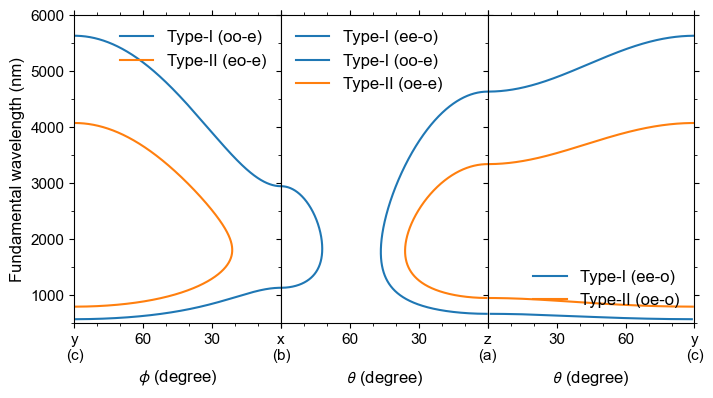

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(8, 4))
axs[0].plot(phi_xy_ooe*180/np.pi, wl_fw_array, label="Type-I (oo-e)", color="C0")
axs[0].plot(phi_xy_eoe*180/np.pi, wl_fw_array, label="Type-II (eo-e)", color="C1")
axs[1].plot(theta_xz_eeo*180/np.pi, wl_fw_array, label="Type-I (ee-o)", color="C0")
axs[1].plot(theta_xz_ooe*180/np.pi, wl_fw_array, label="Type-I (oo-e)", color="C0")
axs[1].plot(theta_xz_oee*180/np.pi, wl_fw_array, label="Type-II (oe-e)", color="C1")
axs[2].plot(theta_yz_eeo*180/np.pi, wl_fw_array, label="Type-I (ee-o)", color="C0")
axs[2].plot(theta_yz_oeo*180/np.pi, wl_fw_array, label="Type-II (oe-o)", color="C1")

axs[0].set_xlim(90, 0)
axs[1].set_xlim(90, 0)
axs[2].set_xlim(0, 90)

axs[1].set_yticklabels([])
axs[2].set_yticklabels([])

axs[0].set_xlabel("$\\phi$ (degree)")
axs[1].set_xlabel("$\\theta$ (degree)")
axs[2].set_xlabel("$\\theta$ (degree)")
axs[0].set_ylabel("Fundamental wavelength (nm)")


for ax in axs:
    ax.tick_params(which='both', top=True, right=True, direction='out')
    ax.set_ylim(500, 6000)
    ax.legend(loc="best", frameon=False)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(500))

axs[0].set_xticks([90, 60, 30, 0])
axs[0].set_xticklabels(["y\n(c)", 60, 30, "x\n(b)"])
axs[1].set_xticks([90, 60, 30, 0])
axs[1].set_xticklabels(["", 60, 30, "z\n(a)"])
axs[2].set_xticks([0, 30, 60, 90])
axs[2].set_xticklabels(["", 30, 60, "y\n(c)"])

fig.subplots_adjust(wspace=0)


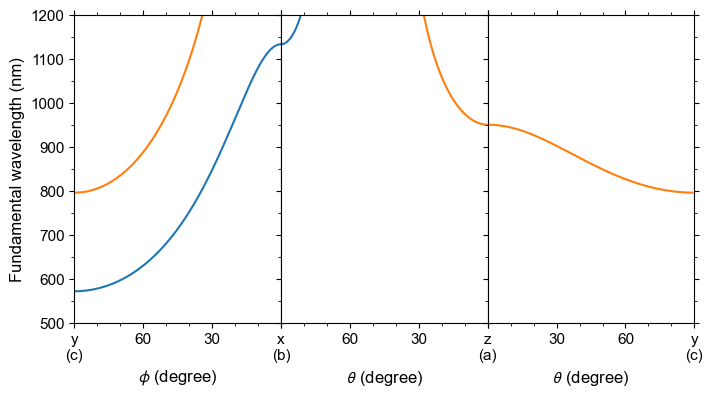

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(8, 4))
axs[0].plot(phi_xy_ooe*180/np.pi, wl_fw_array, label="Type-I (oo-e)", color="C0")
axs[0].plot(phi_xy_eoe*180/np.pi, wl_fw_array, label="Type-II (eo-e)", color="C1")
axs[1].plot(theta_xz_eeo*180/np.pi, wl_fw_array, label="Type-I (ee-o)", color="C0")
# axs[1].plot(theta_xz_ooe*180/np.pi, wl_fw_array, label="Type-I (oo-e)", color="C0")
axs[1].plot(theta_xz_oee*180/np.pi, wl_fw_array, label="Type-II (oe-e)", color="C1")
# axs[2].plot(theta_yz_eeo*180/np.pi, wl_fw_array, label="Type-I (ee-o)", color="C0")
axs[2].plot(theta_yz_oeo*180/np.pi, wl_fw_array, label="Type-II (oe-o)", color="C1")
axs[0].set_xlim(90, 0)
axs[1].set_xlim(90, 0)
axs[2].set_xlim(0, 90)

axs[1].set_yticklabels([])
axs[2].set_yticklabels([])

axs[0].set_xlabel("$\\phi$ (degree)")
axs[1].set_xlabel("$\\theta$ (degree)")
axs[2].set_xlabel("$\\theta$ (degree)")
axs[0].set_ylabel("Fundamental wavelength (nm)")


for ax in axs:
    ax.tick_params(which='both', top=True, right=True, direction='out')
    ax.set_ylim(500, 1200)
    # ax.legend(loc="best", frameon=False)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_minor_locator(MultipleLocator(50))

axs[0].set_xticks([90, 60, 30, 0])
axs[0].set_xticklabels(["y\n(c)", 60, 30, "x\n(b)"])
axs[1].set_xticks([90, 60, 30, 0])
axs[1].set_xticklabels(["", 60, 30, "z\n(a)"])
axs[2].set_xticks([0, 30, 60, 90])
axs[2].set_xticklabels(["", 30, 60, "y\n(c)"])

fig.subplots_adjust(wspace=0)


In [23]:
mask = np.isclose(wl_fw_array, 1064)
if mask.any():
    idx = int(np.flatnonzero(mask)[0])
else:
    idx = int(np.argmin(np.abs(wl_fw_array - 1064)))

phi_xy_ooe_1064 = phi_xy_ooe[idx] * 180 / np.pi
phi_xy_eoe_1064 = phi_xy_eoe[idx] * 180 / np.pi
theta_xz_ooe_1064 = theta_xz_ooe[idx] * 180 / np.pi
theta_xz_oee_1064 = theta_xz_oee[idx] * 180 / np.pi

print(f"At 1064 nm fundamental wavelength:"
f"\n  XY-plane, Type-I (oo-e): phi = {phi_xy_ooe_1064:.2f} degree"
f"\n  XY-plane, Type-II (eo-e): phi = {phi_xy_eoe_1064:.2f} degree"
f"\n  XZ-plane, Type-I (oo-e): theta = {theta_xz_ooe_1064:.2f} degree"
f"\n  XZ-plane, Type-II (oe-e): theta = {theta_xz_oee_1064:.2f} degree")


At 1064 nm fundamental wavelength:
  XY-plane, Type-I (oo-e): phi = 11.65 degree
  XY-plane, Type-II (eo-e): phi = 42.33 degree
  XZ-plane, Type-I (oo-e): theta = 40.05 degree
  XZ-plane, Type-II (oe-e): theta = 20.35 degree


Angle of incidence for actual setting

In [24]:
nx_sh_1064 = BMF_refractive_index(wl_fw_array[idx] * 0.5, "b")
ny_sh_1064 = BMF_refractive_index(wl_fw_array[idx] * 0.5, "c")
nz_sh_1064 = BMF_refractive_index(wl_fw_array[idx] * 0.5, "a")

# XY-plane, Type-I (oo-e): phi = 11.65 degree
phi_xy_ooe_1064_incidence = np.arcsin(n_xy(phi_xy_ooe[idx], nx_sh_1064, ny_sh_1064) * np.sin(phi_xy_ooe[idx]))

# XY-plane, Type-II (eo-e): phi = 42.33 degree
phi_xy_eoe_1064_incidence = np.arcsin(n_xy(phi_xy_eoe[idx], nx_sh_1064, ny_sh_1064) * np.sin(phi_xy_eoe[idx]))

# XZ-plane, Type-I (oo-e): theta = 40.05 degree
theta_xz_ooe_1064_incidence = np.arcsin(n_xz(theta_xz_ooe[idx], nx_sh_1064, nz_sh_1064) * np.sin(theta_xz_ooe[idx]))

# XZ-plane, Type-II (oe-e): theta = 20.35 degree
theta_xz_oee_1064_incidence = np.arcsin(n_xz(theta_xz_oee[idx], nx_sh_1064, nz_sh_1064) * np.sin(theta_xz_oee[idx]))

print(f"At 1064 nm fundamental wavelength:"
f"\n  XY-plane, Type-I (oo-e): incidence angle = {phi_xy_ooe_1064_incidence*180/np.pi:.2f} degree"
f"\n  XY-plane, Type-II (eo-e): incidence angle = {phi_xy_eoe_1064_incidence*180/np.pi:.2f} degree"
f"\n  XZ-plane, Type-I (oo-e): incidence angle = {theta_xz_ooe_1064_incidence*180/np.pi:.2f} degree"
f"\n  XZ-plane, Type-II (oe-e): incidence angle = {theta_xz_oee_1064_incidence*180/np.pi:.2f} degree")

At 1064 nm fundamental wavelength:
  XY-plane, Type-I (oo-e): incidence angle = 17.23 degree
  XY-plane, Type-II (eo-e): incidence angle = 79.36 degree
  XZ-plane, Type-I (oo-e): incidence angle = 69.96 degree
  XZ-plane, Type-II (oe-e): incidence angle = 30.36 degree


In [ ]:
# # xy-plane, Type-I (oo-e)
# theta = 90  # degrees
# data_export = pd.DataFrame({
#     "wavelength_nm": wl_fw_array,
#     "theta_deg": theta,
#     "phi_deg": phi_xy_ooe * 180 / np.pi
# })    
# data_export.to_csv("BMF_xy_type1.csv", index=False)

# # yz-plane, Type-II (oe-o)
# phi = 90
# data_export = pd.DataFrame({
#     "wavelength_nm": wl_fw_array,
#     "theta_deg": theta_yz_oeo * 180 / np.pi,
#     "phi_deg": phi
# })
# data_export.to_csv("BMF_yz_type2.csv", index=False)

# # xz-plane, Type-I (ee-o)
# phi = 0
# data_export = pd.DataFrame({
#     "wavelength_nm": wl_fw_array,
#     "theta_deg": theta_xz_eeo * 180 / np.pi,
#     "phi_deg": phi
# })
# data_export.to_csv("BMF_xz_type1.csv", index=False)

# # xz-plane, Type-II (oe-e)
# phi = 0
# data_export = pd.DataFrame({
#     "wavelength_nm": wl_fw_array,
#     "theta_deg": theta_xz_oee * 180 / np.pi,
#     "phi_deg": phi
# })
# data_export.to_csv("BMF_xz_type2.csv", index=False)
